In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import re

from IPython.display import display

In [2]:
def calculate_apdex(df, threshold=500):
    satisfied = (df['elapsed'] <= threshold).sum()
    tolerating = ((df['elapsed'] > threshold) & (df['elapsed'] <= 4 * threshold)).sum()
    total = len(df)
    return (satisfied + tolerating / 2) / total if total > 0 else 0.0

In [3]:
def process_file(file, apdex_threshold=500):
    df = pd.read_csv(file, sep=';', encoding='utf-8-sig', low_memory=False, dtype={'responseCode': str})
    df.columns = df.columns.str.strip().str.lower()

    df['success'] = df['success'].astype(str).str.lower() == 'true'

    total = len(df)
    success = df['success'].sum()
    error = total - success

    match = re.search(r'Incremental.*?(\d+)', file, re.IGNORECASE)
    users = int(match.group(1)) if match else None

    if not df.empty:
        start_time = df['timestamp'].min()
        end_time = df['timestamp'].max()
        duration_sec = (end_time - start_time) / 1000.0
        throughput = total / duration_sec if duration_sec > 0 else 0
    else:
        throughput = 0

    p90 = df['elapsed'].quantile(0.90) if not df.empty else 0
    p95 = df['elapsed'].quantile(0.95) if not df.empty else 0
    p99 = df['elapsed'].quantile(0.99) if not df.empty else 0

    cache_hit_rate = 0.0
    
    cache_col = None
    for col in df.columns:
        if 'cache' in col and 'status' in col:
            cache_col = col
            break
   
    if cache_col:
        df[cache_col] = df[cache_col].astype(str).str.upper().str.strip()
        
        cache_hit = (df[cache_col] == 'NONE').sum()
        total_cache = df[cache_col].isin(['NONE', 'HIT', 'MISS', 'BYPASS']).sum()
        
        cache_hit_rate = (cache_hit / total_cache * 100) if total_cache > 0 else 0

    waf_active_rate = 0.0

    waf_col = None
    for col in df.columns:
        if 'waf' in col and 'status' in col:
            waf_col = col
            break
    
    if waf_col:
        df[waf_col] = df[waf_col].astype(str).str.upper().str.strip()
        
        waf_active = (df[waf_col] == 'ACTIVE').sum()
        total_waf = df[waf_col].isin(['ACTIVE', 'INACTIVE']).sum()
        
        waf_active_rate = (waf_active / total_waf * 100) if total_waf > 0 else 0
        
    apdex = calculate_apdex(df, threshold=apdex_threshold)

    return {
        'users': users,
        'total_requests': total,
        'success_rate (%)': round(success / total * 100, 2) if total > 0 else 0,
        'error_rate (%)': round(error / total * 100, 2) if total > 0 else 0,
        'avg_response (ms)': round(df['elapsed'].mean(), 2) if not df.empty else 0,
        'p90_response (ms)': round(p90, 2),
        'p95_response (ms)': round(p95, 2),
        'avg_latency (ms)': round(df['latency'].mean(), 2) if not df.empty else 0,
        'avg_connect (ms)': round(df['connect'].mean(), 2) if 'connect' in df.columns and not df.empty else 0,
        'throughput (req/s)': round(throughput, 2),
        'cache none (%)': round(cache_hit_rate, 2),
        'waf active (%)': round(waf_active_rate, 2),
        'apdex': round(apdex, 3),
    }

In [4]:
def analyze_all(pattern="IncrementalReport/Wordpress Report - Incremental*.csv", apdex_threshold=500):
    files = glob.glob(pattern)
    if not files:
        print(f"Format file salah: {pattern}")
        return pd.DataFrame()

    results = []
    for f in sorted(files):
        results.append(process_file(f, apdex_threshold))

    df_result = pd.DataFrame(results)

    if df_result['users'].notna().all():
        df_result = df_result.sort_values(by='users').reset_index(drop=True)

    numeric_cols = df_result.select_dtypes(include='number').columns
    avg_values = df_result[numeric_cols].mean()

    avg_row = avg_values.to_dict()
    avg_row['users'] = 'Average'

    df_final = pd.concat([df_result, pd.DataFrame([avg_row])], ignore_index=True)

    cols = ['users'] + [col for col in df_final.columns if col != 'users']
    df_final = df_final[cols]

    return df_final

In [5]:
result = analyze_all("IncrementalReport/Wordpress Report - Incremental Bypass*.csv", apdex_threshold=500)
result.to_csv("Wordpress Report - Incremental Bypass Summary.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=2)
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(result)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

users,total_requests,success_rate (%),error_rate (%),avg_response (ms),p90_response (ms),p95_response (ms),avg_latency (ms),avg_connect (ms),throughput (req/s),cache none (%),waf active (%),apdex
100,300388.00,0.00,100.00,180.07,267.00,312.00,178.59,1.28,500.68,100.00,100.00,1.00
200,291525.00,0.00,100.00,371.36,559.00,666.00,363.03,5.34,485.94,100.00,99.98,0.92
300,316732.00,0.00,100.00,512.13,860.00,1021.00,503.71,7.68,527.97,100.00,99.99,0.77
400,316538.00,0.00,100.00,700.37,1088.00,1301.00,634.43,56.42,527.59,100.00,99.96,0.69
500,317202.00,0.00,100.00,882.63,1253.00,1470.00,753.31,101.07,528.70,100.00,99.91,0.63
Average,308477.00,0.00,100.00,529.31,805.40,954.00,486.61,34.36,514.18,100.00,99.97,0.80


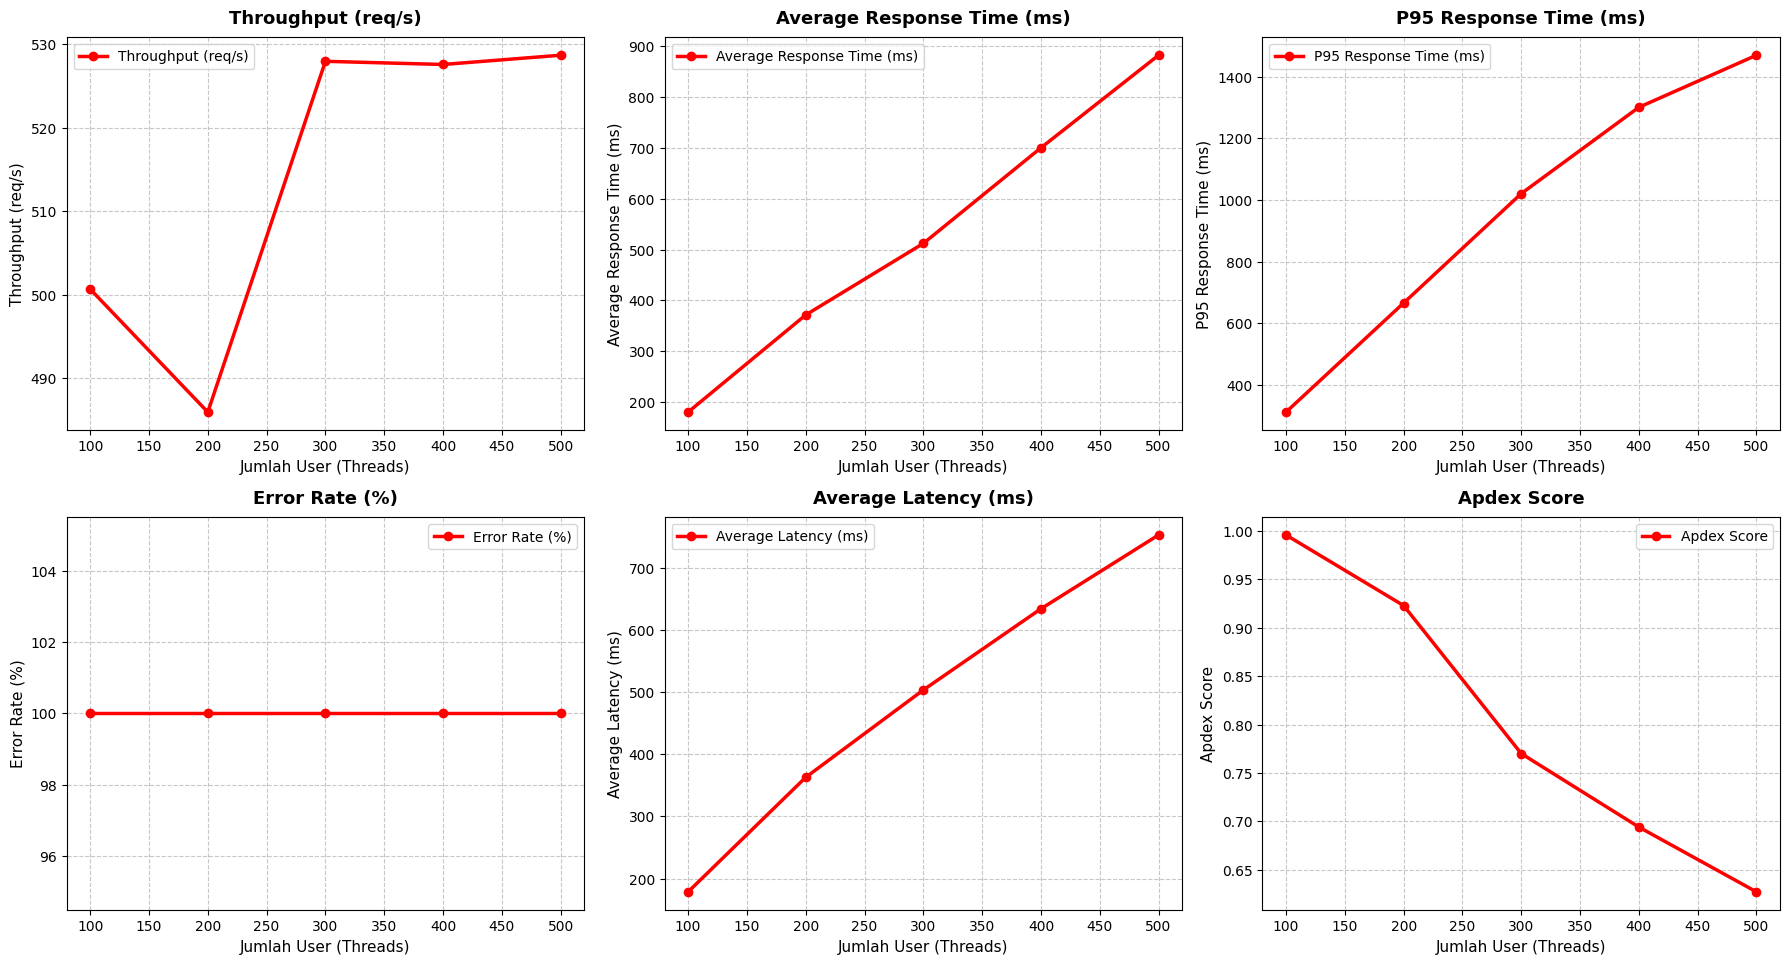

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = result['users'][:-1]

metrics = [
    ('throughput (req/s)',    'Throughput (req/s)',          'red'),
    ('avg_response (ms)',     'Average Response Time (ms)',  'red'),
    ('p95_response (ms)',     'P95 Response Time (ms)',      'red'),
    ('error_rate (%)',        'Error Rate (%)',              'red'),
    ('avg_latency (ms)',      'Average Latency (ms)',        'red'),
    ('apdex',                 'Apdex Score',                 'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, result[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Wordpress Report - Incremental Bypass.png")
plt.show()

In [7]:
def clean_cpu(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    value = float(match.group(1))
    if 'm' in val_str:
        return value
    else:
        return value * 1000

In [8]:
def clean_memory(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    
    value = float(match.group(1))
    
    if 'gi' in val_str:
        return value * 1024
    elif 'mi' in val_str or 'mib' in val_str:
        return value
    elif 'ki' in val_str:
        return value / 1024
    else:
        return value

In [9]:
pattern = "IncrementalResult/log_wordpress-incremental*.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_bypass-(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_cleaned'] = df['App_CPU_m'].apply(clean_cpu)
        df['Memory_cleaned'] = df['App_Memory_Mi'].apply(clean_memory)
        df['Ingress_CPU_cleaned'] = df['Ingress_CPU_m'].apply(clean_cpu)
        df['Ingress_Memory_cleaned'] = df['Ingress_Memory_Mi'].apply(clean_memory)

        pods = df['Pod_Name'][df['Pod_Name'].str.startswith('wordpress-deployment', na=False)]
        pod_count = pods.nunique()
        
        avg_cpu = df['CPU_cleaned'].mean()
        max_cpu = df['CPU_cleaned'].max()
        avg_mem = df['Memory_cleaned'].mean()
        max_mem = df['Memory_cleaned'].max()
        avg_ingress_cpu = df['Ingress_CPU_cleaned'].mean()
        max_ingress_cpu = df['Ingress_CPU_cleaned'].max()
        avg_ingress_mem = df['Ingress_Memory_cleaned'].mean()
        max_ingress_mem = df['Ingress_Memory_cleaned'].max()

        modsecurity_blocked_rate = 0.0
        
        modsecurity_col = None
        for col in df.columns:
            col_lower = col.lower().replace('_', '').replace(' ', '')
            if 'modsecurity' in col.lower() and 'status' in col.lower():
                modsecurity_col = col
                break
        
        if modsecurity_col:
            df[modsecurity_col] = df[modsecurity_col].astype(str).str.upper().str.strip()
            
            blocked = (df[modsecurity_col] == 'BLOCKED').sum()
            total_modsecurity = len(df)
            
            modsecurity_blocked_rate = (blocked / total_modsecurity * 100) if total_modsecurity > 0 else 0
            
        results.append({
            'Users': user_count,
            'Replicas': int(pod_count),
            'Avg CPU (m)': round(avg_cpu, 2),
            'Max CPU (m)': round(max_cpu, 2),
            'Avg Memory (Mi)': round(avg_mem, 2),
            'Max Memory (Mi)': round(max_mem, 2),
            'Avg Ingress CPU (m)': round(avg_ingress_cpu, 2),
            'Max Ingress CPU (m)': round(max_ingress_cpu, 2),
            'Avg Ingress Memory (Mi)': round(avg_ingress_mem, 2),
            'Max Ingress Memory (Mi)': round(max_ingress_mem, 2),
            'ModSecurity Blocked (%)': round(modsecurity_blocked_rate, 2),
            'Samples': len(df)
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Users').reset_index(drop=True)

In [10]:
numeric_cols = ['Avg CPU (m)', 'Replicas', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Avg Ingress CPU (m)', 'Max Ingress CPU (m)', 'Avg Ingress Memory (Mi)', 'Max Ingress Memory (Mi)', 'ModSecurity Blocked (%)', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Wordpress Result - Incremental Bypass Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .format(subset=['Replicas', 'Samples'], formatter="{:.0f}")
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Replicas,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Avg Ingress CPU (m),Max Ingress CPU (m),Avg Ingress Memory (Mi),Max Ingress Memory (Mi),ModSecurity Blocked (%),Samples
100,1,2.48,4.00,245.00,444.00,1219.38,1481.00,67.23,68.00,100.00,266
200,1,2.50,4.00,270.50,448.00,1016.70,1498.00,70.39,73.00,100.00,302
300,1,2.49,4.00,270.50,448.00,1294.26,1514.00,73.31,76.00,99.21,254
400,1,2.50,4.00,275.50,449.00,1124.71,1510.00,74.01,79.00,100.00,298
500,1,2.44,4.00,275.50,449.00,1168.24,1527.00,76.05,82.00,79.72,286
Average,1,2.48,4.00,267.40,447.60,1164.66,1506.00,72.20,75.60,95.79,281


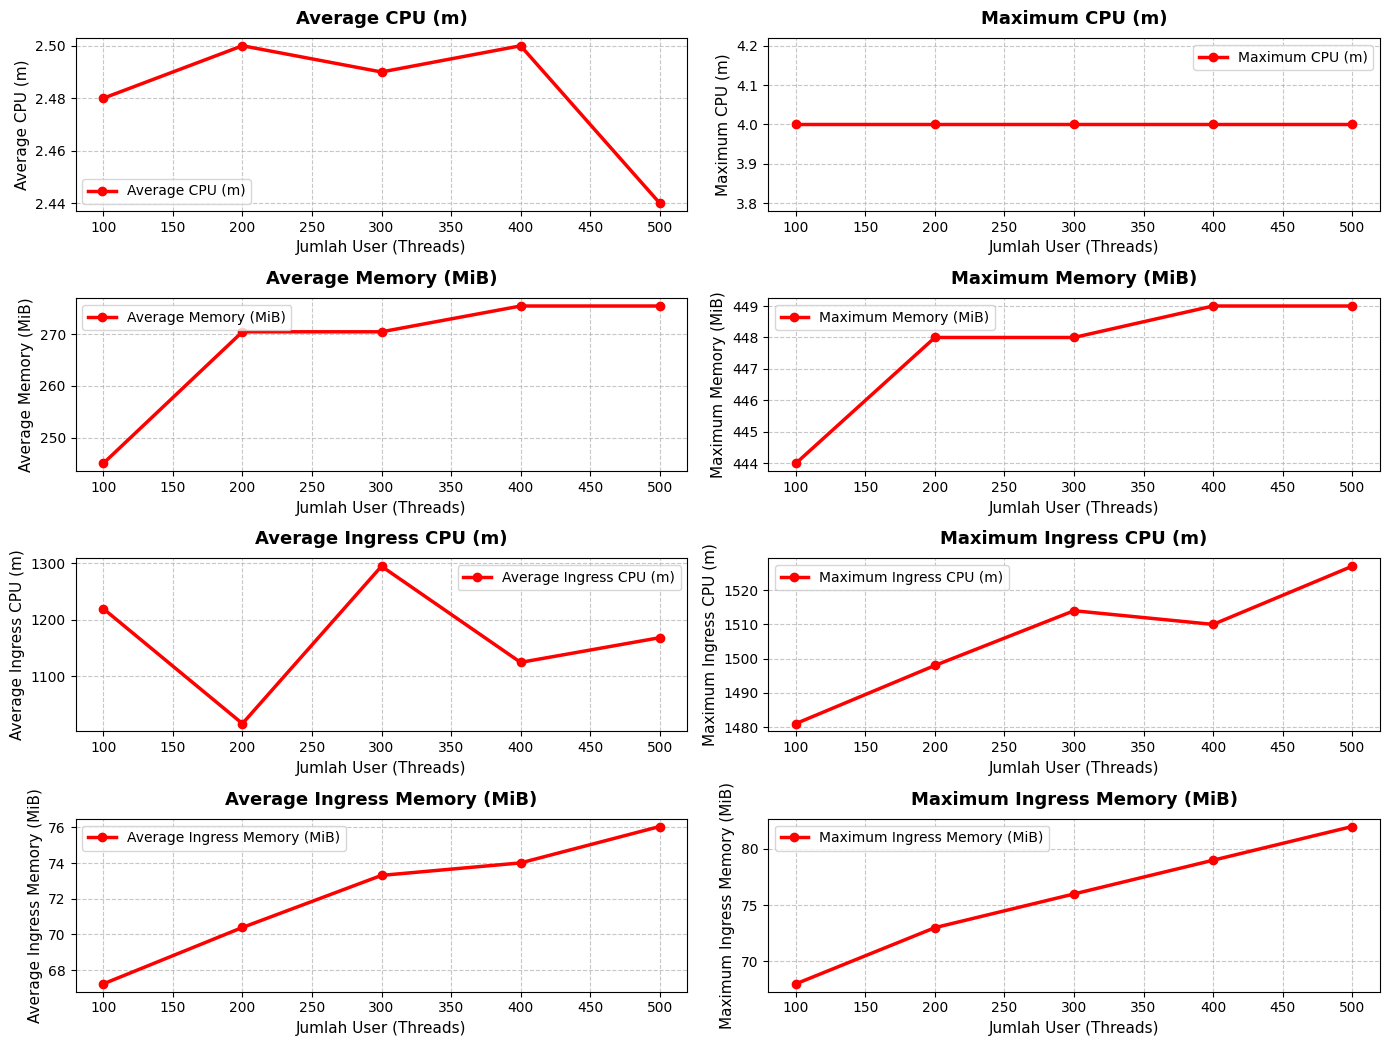

In [11]:
fig, axs = plt.subplots(4, 2, figsize=(14, 11))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (m)',             'Average CPU (m)',              'red'),
    ('Max CPU (m)',             'Maximum CPU (m)',              'red'),
    ('Avg Memory (Mi)',         'Average Memory (MiB)',         'red'),
    ('Max Memory (Mi)',         'Maximum Memory (MiB)',         'red'),
    ('Avg Ingress CPU (m)',     'Average Ingress CPU (m)',      'red'),
    ('Max Ingress CPU (m)',     'Maximum Ingress CPU (m)',      'red'),
    ('Avg Ingress Memory (Mi)', 'Average Ingress Memory (MiB)', 'red'),
    ('Max Ingress Memory (Mi)', 'Maximum Ingress Memory (MiB)', 'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 2)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Wordpress Result - Incremental Bypass.png")
plt.show()

In [12]:
pattern = "IncrementalKernel/log-kernel-monitoring_wordpress-incremental*.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_bypass-(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_Total'] = df['CPU_User'] + df['CPU_System']
        df['Memory_Total'] = df['Mem_Free_MB'] + df['Mem_Cache_MB']
        df['IO_Total'] = df['IO_Read_S'] + df['IO_Write_S']

        avg_cpu = df['CPU_Total'].mean()
        max_cpu = df['CPU_Total'].max()
        iowait = df['CPU_IOWait'].mean()
        
        load_avg = df['Load_Avg'].mean()

        avg_mem = df['Memory_Total'].mean()
        max_mem = df['Memory_Total'].max()

        avg_io = df['IO_Total'].mean()
        max_io = df['IO_Total'].max()
        
        duration_minutes = (df['Epoch'].max() - df['Epoch'].min()) / 60 if not df.empty else 0
        
        context_switches = df['Context_Switches'].mean()
        
        results.append({
            'Users': user_count,
            'Avg CPU (%)': round(avg_cpu, 2),
            'Max CPU (%)': round(max_cpu, 2),
            'CPU IOWait': round(iowait, 2),
            'Load Avg': round(load_avg, 2),
            'Avg Memory (MB)': round(avg_mem, 2),
            'Max Memory (MB)': round(max_mem, 2),
            'Avg I/O (S)': round(avg_io, 2),
            'Max I/O (S)': round(max_io, 2),
            'Context Switches': round(context_switches, 2),
            'Duration (s)': round(duration_minutes, 1),
            'Samples': len(df),
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Users').reset_index(drop=True)

In [13]:
numeric_cols = ['Avg CPU (%)', 'Max CPU (%)', 'CPU IOWait', 'Load Avg', 'Avg Memory (MB)', 'Max Memory (MB)', 'Avg I/O (S)', 'Max I/O (S)', 'Context Switches', 'Duration (s)', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Wordpress Kernel - Incremental Bypass Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .format(subset=['Context Switches', 'Samples'], formatter="{:.0f}")
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Avg CPU (%),Max CPU (%),CPU IOWait,Load Avg,Avg Memory (MB),Max Memory (MB),Avg I/O (S),Max I/O (S),Context Switches,Duration (s),Samples
100,80.92,101.00,0.63,4.01,4382.78,4409.00,734.25,11844.00,25955,11.80,98
200,70.28,101.00,0.80,6.10,4321.66,4349.00,533.48,15944.00,24143,13.30,109
300,87.38,101.00,0.33,9.58,4308.80,4333.00,264.94,608.00,27594,11.10,87
400,72.20,101.00,0.73,7.34,4301.94,4334.00,814.79,11888.00,24641,13.60,107
500,75.97,101.00,0.56,7.87,4292.44,4332.00,840.30,12126.73,25061,12.80,100
Average,77.35,101.00,0.61,6.98,4321.52,4351.40,637.55,10482.15,25479,12.52,100


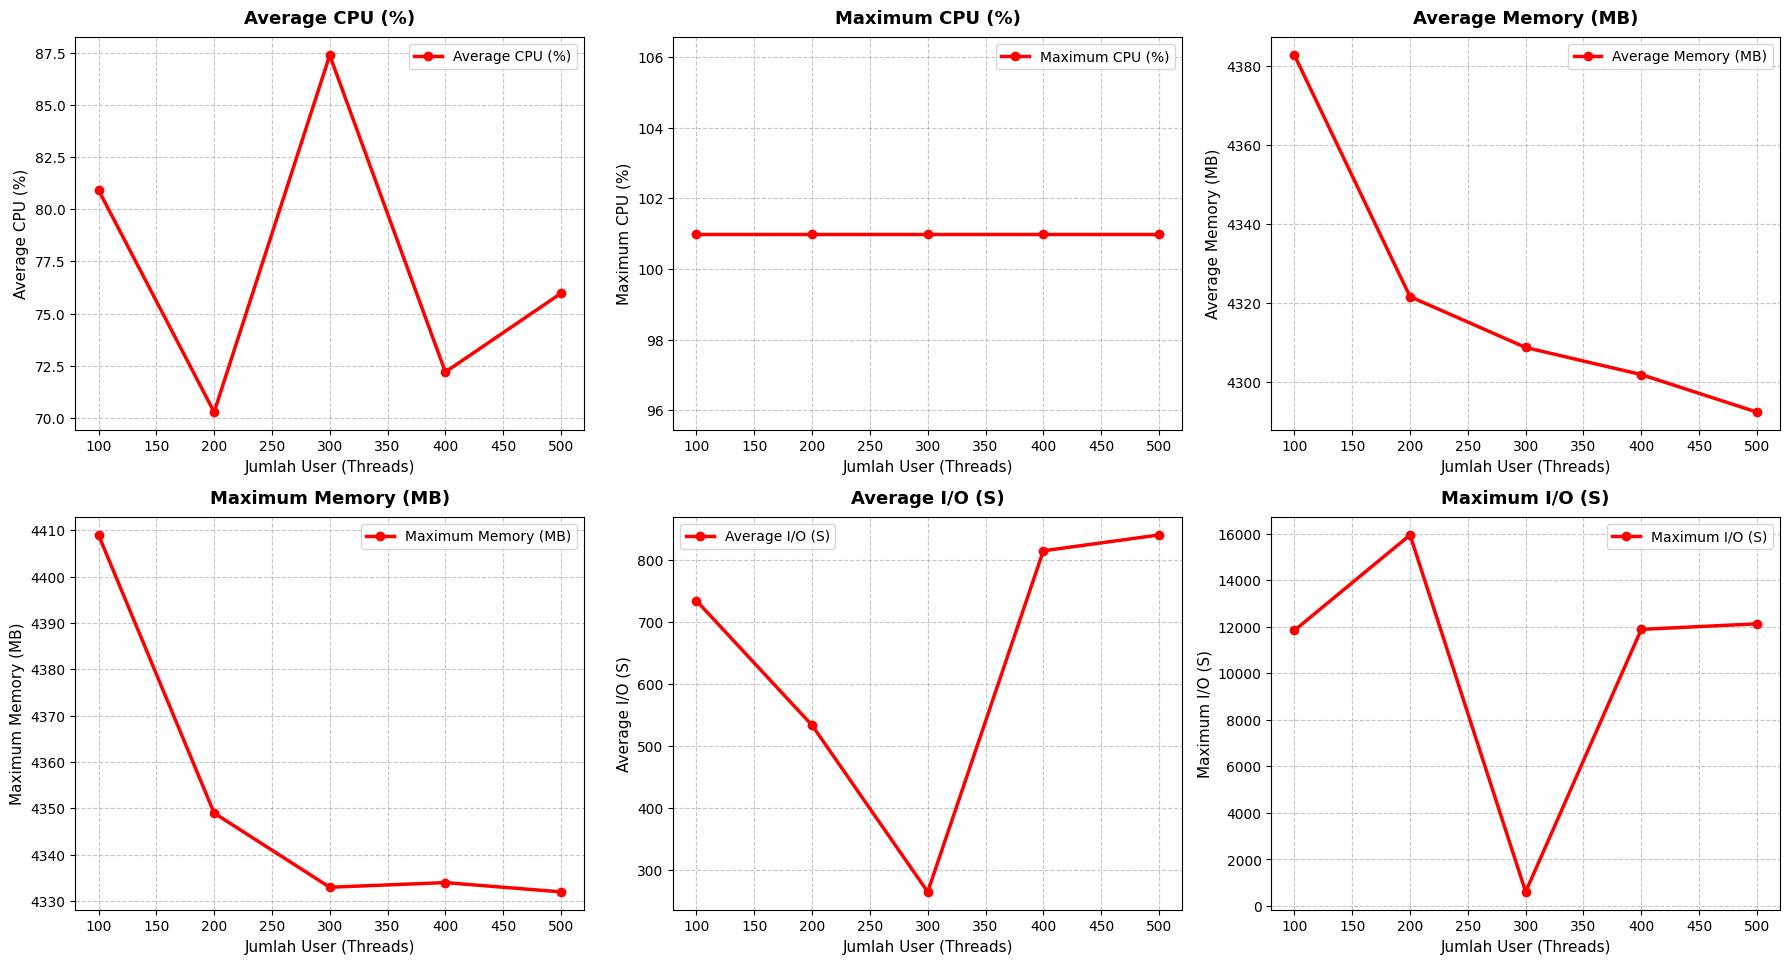

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (%)',     'Average CPU (%)',            'red'),
    ('Max CPU (%)',     'Maximum CPU (%)',            'red'),
    ('Avg Memory (MB)', 'Average Memory (MB)',        'red'),
    ('Max Memory (MB)', 'Maximum Memory (MB)',        'red'),
    ('Avg I/O (S)',     'Average I/O (S)',            'red'), 
    ('Max I/O (S)',     'Maximum I/O (S)',            'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Wordpress Kernel - Incremental Bypass.png")
plt.show()